In [1]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load the banking customer dataset
bank_df = pd.read_csv("banking-clients.csv")

# Preview first 5 customer records
bank_df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,5473.15,2,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [2]:
# Check dataset dimensions
print("Total Rows:", bank_df.shape[0])
print("Total Columns:", bank_df.shape[1])

Total Rows: 3000
Total Columns: 25


In [3]:
# Display column names
bank_df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [7]:
# Dataset dimensions
rows, cols = bank_df.shape
print(f"Dataset contains {rows} rows and {cols} columns")

Dataset contains 3000 rows and 25 columns


In [8]:
# Data types and non-null values
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [9]:
# Summary statistics for numerical banking variables
numeric_summary = bank_df.describe().T
numeric_summary[['mean', '50%', 'min', 'max', 'std']]

,mean,50%,min,max,std
Age,51.04,51.00,17.00,85.00,19.85
Location ID,21563.32,21129.50,12.00,43369.00,12462.27
Estimated Income,171305.03,142313.48,15919.48,522330.26,111935.81
Superannuation Savings,25531.60,22357.36,1482.03,75963.90,16259.95
Amount of Credit Cards,1.46,1.00,1.00,3.00,0.68
Credit Card Balance,3176.21,2560.81,1.17,13991.99,2497.09
Bank Loans,591386.16,479793.40,0.00,2667556.66,457557.04
Bank Deposits,671560.19,463316.46,0.00,3890598.08,645716.86
Checking Accounts,321092.95,242815.65,0.00,1969923.08,282079.55
Saving Accounts,232908.35,164086.55,0.00,1724118.36,230007.78


In [10]:
# Financial summary of key banking metrics
financial_cols = [
    'Estimated Income',
    'Bank Deposits',
    'Bank Loans',
    'Checking Accounts',
    'Saving Accounts',
    'Credit Card Balance',
    'Business Lending'
]
bank_df[financial_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated Income,3000.00,171305.03,111935.81,15919.48,82906.60,142313.48,242290.30,522330.26
Bank Deposits,3000.00,671560.19,645716.86,0.00,204400.38,463316.46,942754.63,3890598.08
Bank Loans,3000.00,591386.16,457557.04,0.00,239628.14,479793.40,825813.04,2667556.66
Checking Accounts,3000.00,321092.95,282079.55,0.00,119947.53,242815.65,434874.94,1969923.08
Saving Accounts,3000.00,232908.35,230007.78,0.00,74794.40,164086.55,315575.00,1724118.36
Credit Card Balance,3000.00,3176.21,2497.09,1.17,1236.63,2560.81,4522.63,13991.99
Business Lending,3000.00,866759.81,641230.32,0.00,374825.14,711314.66,1185110.07,3825961.94


In [11]:
# Create income segments for customer profiling
income_bins = [0, 100000, 300000, np.inf]
income_labels = ['Low Income', 'Middle Income', 'High Income']

bank_df['Income Segment'] = pd.cut(
    bank_df['Estimated Income'],
    bins=income_bins,
    labels=income_labels,
    right=False
)
bank_df[['Estimated Income', 'Income Segment']].head()

,Estimated Income,Income Segment
0,75384.77,Low Income
1,289834.31,Middle Income
2,169935.23,Middle Income
3,356808.11,High Income
4,130711.68,Middle Income


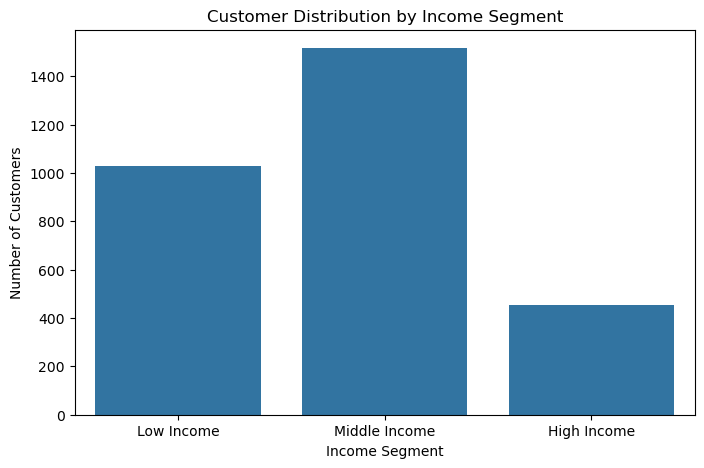

In [12]:
# Income segment distribution
income_segment_counts = bank_df['Income Segment'].value_counts().reset_index()
income_segment_counts.columns = ['Income Segment', 'Customer Count']

plt.figure(figsize=(8, 5))
sns.barplot(data=income_segment_counts, x='Income Segment', y='Customer Count')
plt.title('Customer Distribution by Income Segment')
plt.xlabel('Income Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [13]:
# Decode ID-based columns for better readability

bank_df['Gender'] = bank_df['GenderId'].map({
    1: 'Male',
    2: 'Female'
})

bank_df['Banking Relationship'] = bank_df['BRId'].map({
    1: 'Retail',
    2: 'Institutional',
    3: 'Private Bank',
    4: 'Commercial'
})

In [16]:
# Categorical feature profiling

categorical_features = [
    'Banking Relationship',
    'Gender',
    'IAId',
    'Amount of Credit Cards',
    'Nationality',
    'Occupation',
    'Fee Structure',
    'Loyalty Classification',
    'Properties Owned',
    'Risk Weighting',
    'Income Segment'
]

category_summary = []

for col in categorical_features:
    category_summary.append({
        'Column': col,
        'Unique Categories': bank_df[col].nunique(),
        'Most Frequent Category': bank_df[col].mode()[0],
        'Frequency': bank_df[col].value_counts().iloc[0]
    })
category_summary_df = pd.DataFrame(category_summary)
category_summary_df

,Column,Unique Categories,Most Frequent Category,Frequency
0,Banking Relationship,4,Private Bank,1352
1,Gender,2,Female,1512
2,IAId,22,1,177
3,Amount of Credit Cards,3,1,1922
4,Nationality,5,European,1309
5,Occupation,195,Associate Professor,28
6,Fee Structure,3,High,1476
7,Loyalty Classification,4,Jade,1331
8,Properties Owned,4,2,777
9,Risk Weighting,5,2,1222


In [15]:
# Top 10 investment advisors by customer count

top_advisors = bank_df['IAId'].value_counts().head(10).reset_index()
top_advisors.columns = ['Investment Advisor ID', 'Customer Count']

top_advisors

,Investment Advisor ID,Customer Count
0,1,177
1,3,177
2,4,177
3,8,177
4,2,177
5,11,176
6,15,176
7,14,176
8,13,176
9,12,176


### Insight: Univariate Customer Profile Distribution
The univariate analysis highlights the distribution of customers across key attributes such as banking relationship, gender, nationality, occupation, loyalty classification, and risk weighting.
It shows that the customer base is primarily concentrated in specific dominant categories, with a balanced gender distribution, higher representation from certain nationalities, and a majority of customers falling under mid-level income, moderate risk, and standard loyalty segments. Overall, the data indicates a stable and moderately diversified customer profile.

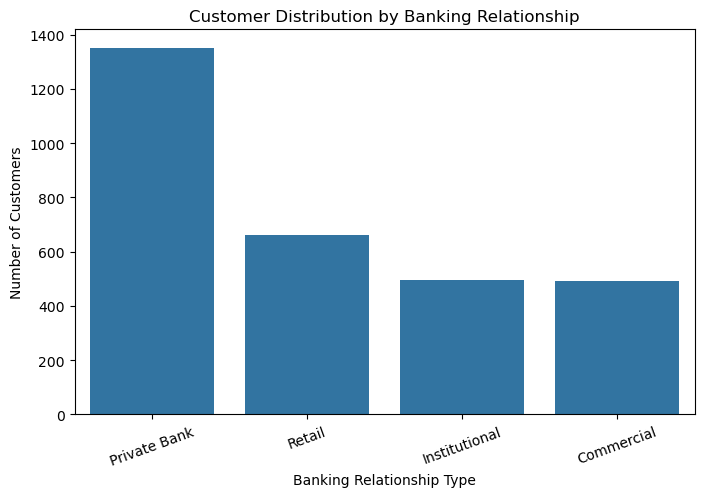

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=bank_df, x='Banking Relationship', order=bank_df['Banking Relationship'].value_counts().index)
plt.title('Customer Distribution by Banking Relationship')
plt.xlabel('Banking Relationship Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

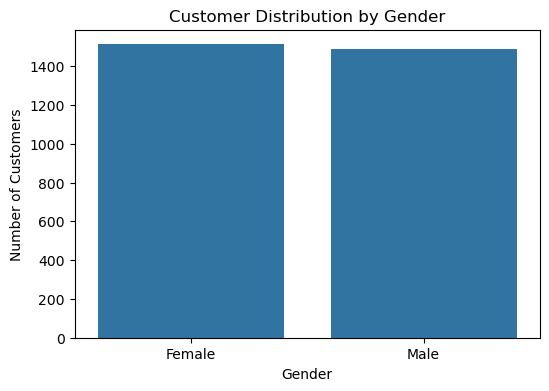

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=bank_df, x='Gender', order=bank_df['Gender'].value_counts().index)
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

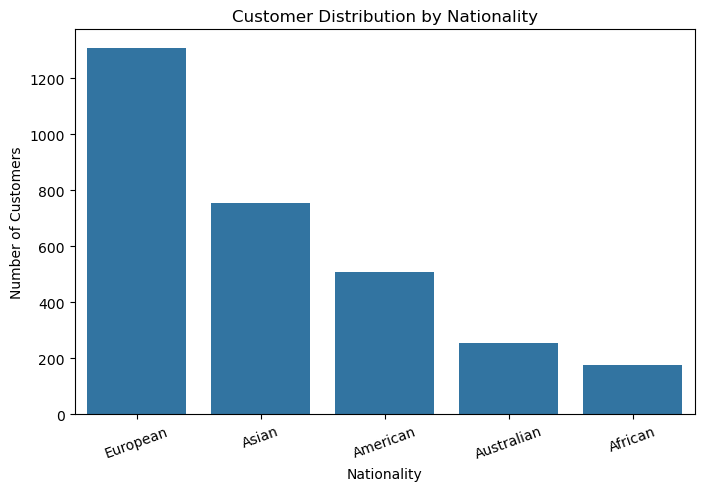

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=bank_df, x='Nationality', order=bank_df['Nationality'].value_counts().index)
plt.title('Customer Distribution by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

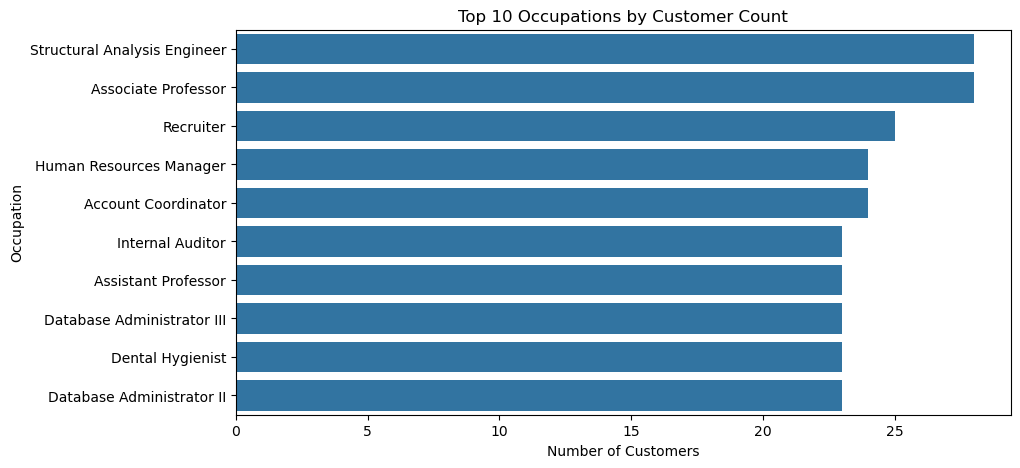

In [20]:
top_occupations = bank_df['Occupation'].value_counts().head(10).reset_index()
top_occupations.columns = ['Occupation', 'Customer Count']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_occupations, y='Occupation', x='Customer Count')
plt.title('Top 10 Occupations by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('Occupation')
plt.show()

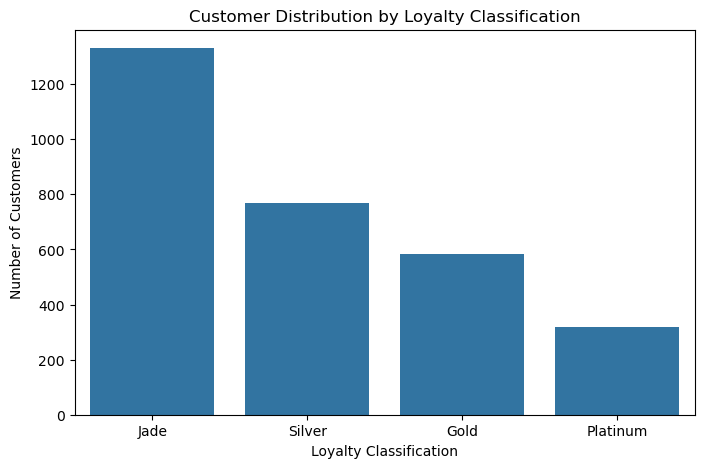

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=bank_df,
    x='Loyalty Classification',
    order=bank_df['Loyalty Classification'].value_counts().index
)
plt.title('Customer Distribution by Loyalty Classification')
plt.xlabel('Loyalty Classification')
plt.ylabel('Number of Customers')
plt.show()

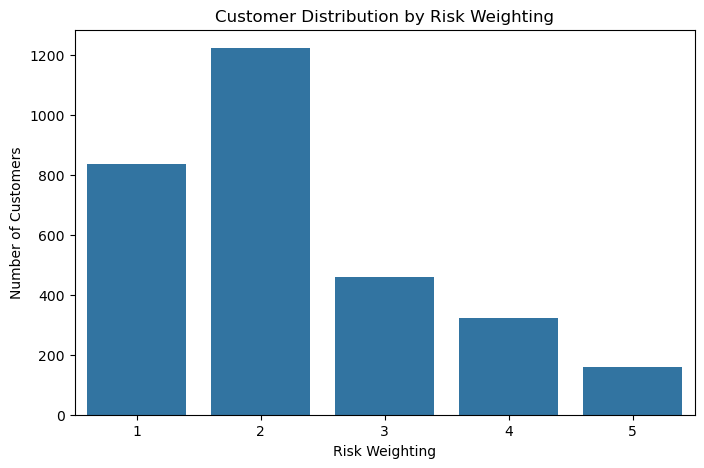

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=bank_df,
    x='Risk Weighting',
    order=sorted(bank_df['Risk Weighting'].unique())
)
plt.title('Customer Distribution by Risk Weighting')
plt.xlabel('Risk Weighting')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Bivariate Analysis
The bivariate analysis focuses on business-relevant comparisons instead of plotting every categorical variable against nationality. Income segments, banking relationship, loyalty classification, and risk weighting are compared to understand customer value, financial behavior, and potential credit risk.

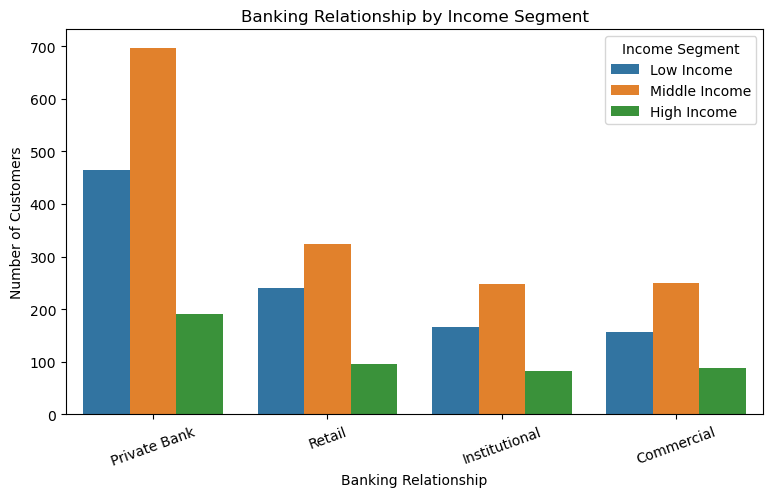

In [23]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=bank_df,
    x='Banking Relationship',
    hue='Income Segment',
    order=bank_df['Banking Relationship'].value_counts().index
)
plt.title('Banking Relationship by Income Segment')
plt.xlabel('Banking Relationship')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.legend(title='Income Segment')
plt.show()

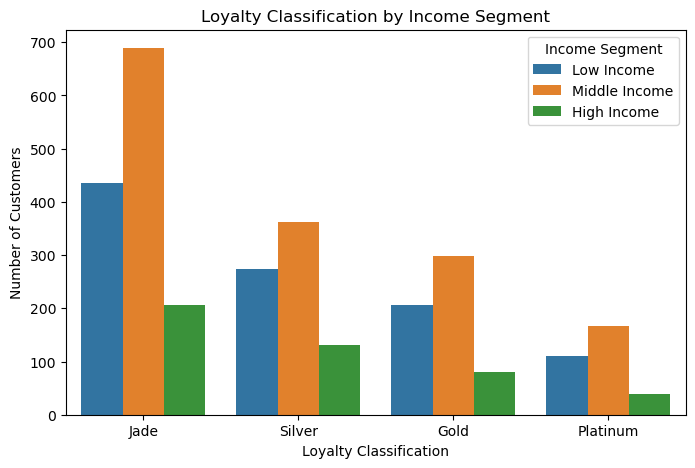

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=bank_df,
    x='Loyalty Classification',
    hue='Income Segment',
    order=bank_df['Loyalty Classification'].value_counts().index
)
plt.title('Loyalty Classification by Income Segment')
plt.xlabel('Loyalty Classification')
plt.ylabel('Number of Customers')
plt.legend(title='Income Segment')
plt.show()

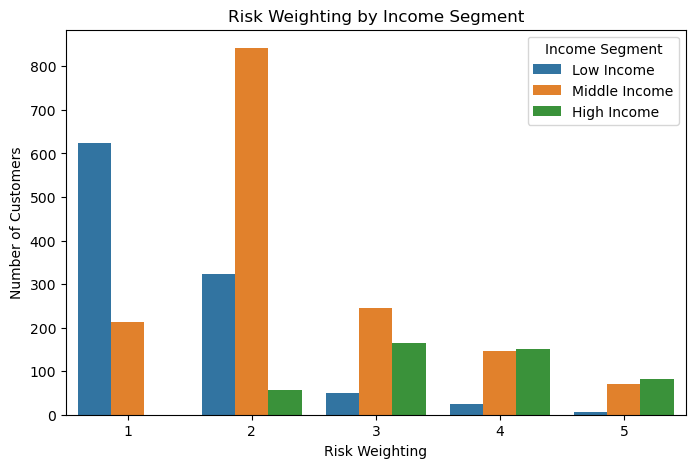

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=bank_df,
    x='Risk Weighting',
    hue='Income Segment',
    order=sorted(bank_df['Risk Weighting'].unique())
)
plt.title('Risk Weighting by Income Segment')
plt.xlabel('Risk Weighting')
plt.ylabel('Number of Customers')
plt.legend(title='Income Segment')
plt.show()

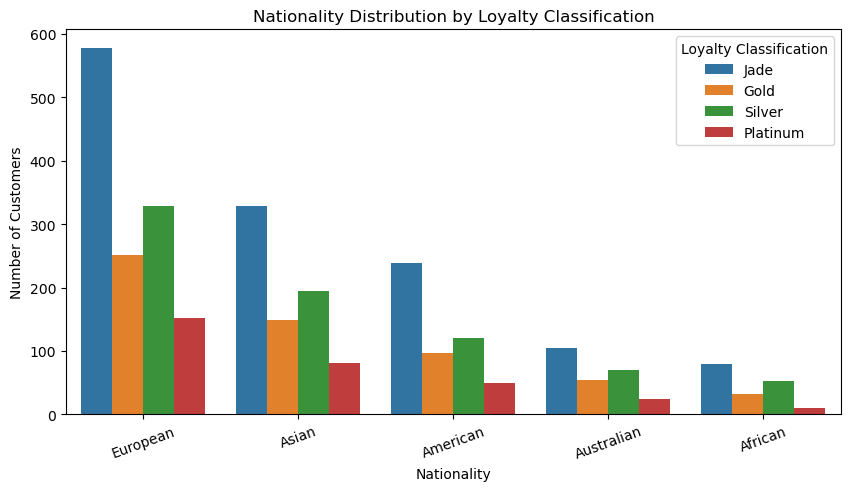

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=bank_df,
    x='Nationality',
    hue='Loyalty Classification',
    order=bank_df['Nationality'].value_counts().index
)
plt.title('Nationality Distribution by Loyalty Classification')
plt.xlabel('Nationality')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.legend(title='Loyalty Classification')
plt.show()

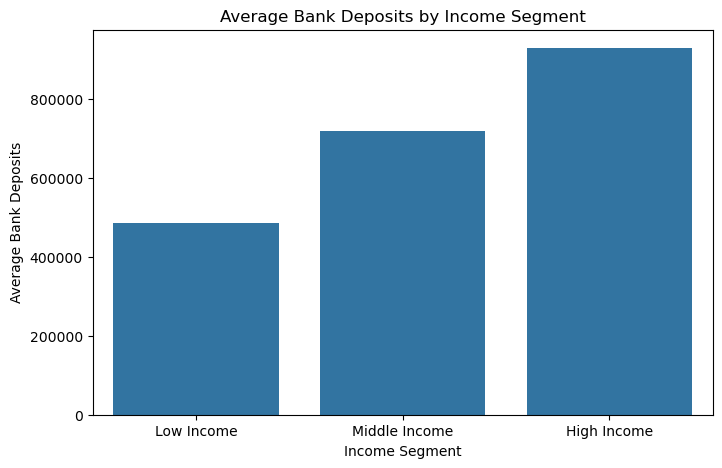

In [28]:
income_deposit_summary = bank_df.groupby(
    'Income Segment',
    observed=False
)['Bank Deposits'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=income_deposit_summary, x='Income Segment', y='Bank Deposits')
plt.title('Average Bank Deposits by Income Segment')
plt.xlabel('Income Segment')
plt.ylabel('Average Bank Deposits')
plt.show()

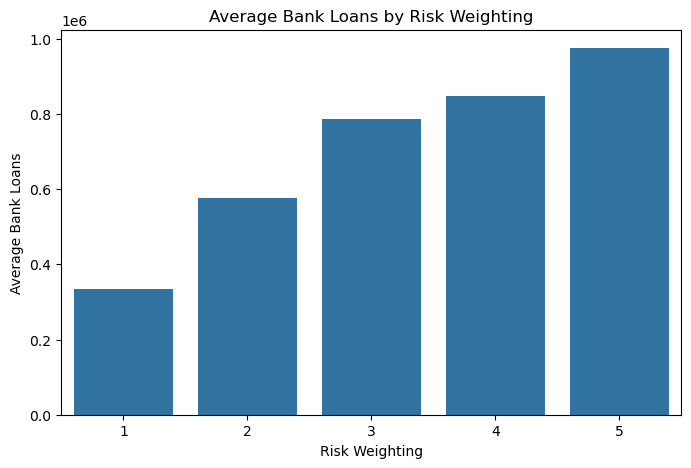

In [29]:
risk_loan_summary = bank_df.groupby('Risk Weighting')['Bank Loans'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=risk_loan_summary, x='Risk Weighting', y='Bank Loans')
plt.title('Average Bank Loans by Risk Weighting')
plt.xlabel('Risk Weighting')
plt.ylabel('Average Bank Loans')
plt.show()

### Insight: Numerical Analysis

The numerical analysis shows that most financial variables such as estimated income, bank deposits, loans, savings, checking accounts, credit card balance, and business lending are right-skewed. This means most customers have moderate financial values, while a smaller group of customers holds very high balances or loan amounts.

Age is more evenly distributed compared to financial variables, indicating that the dataset contains customers from different age groups. Overall, this section helps identify customer value distribution, financial concentration, and the presence of high-value customers.

In [30]:
# Selecting numerical columns for distribution analysis

numerical_cols = [
    'Age',
    'Estimated Income',
    'Superannuation Savings',
    'Credit Card Balance',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account',
    'Business Lending'
]

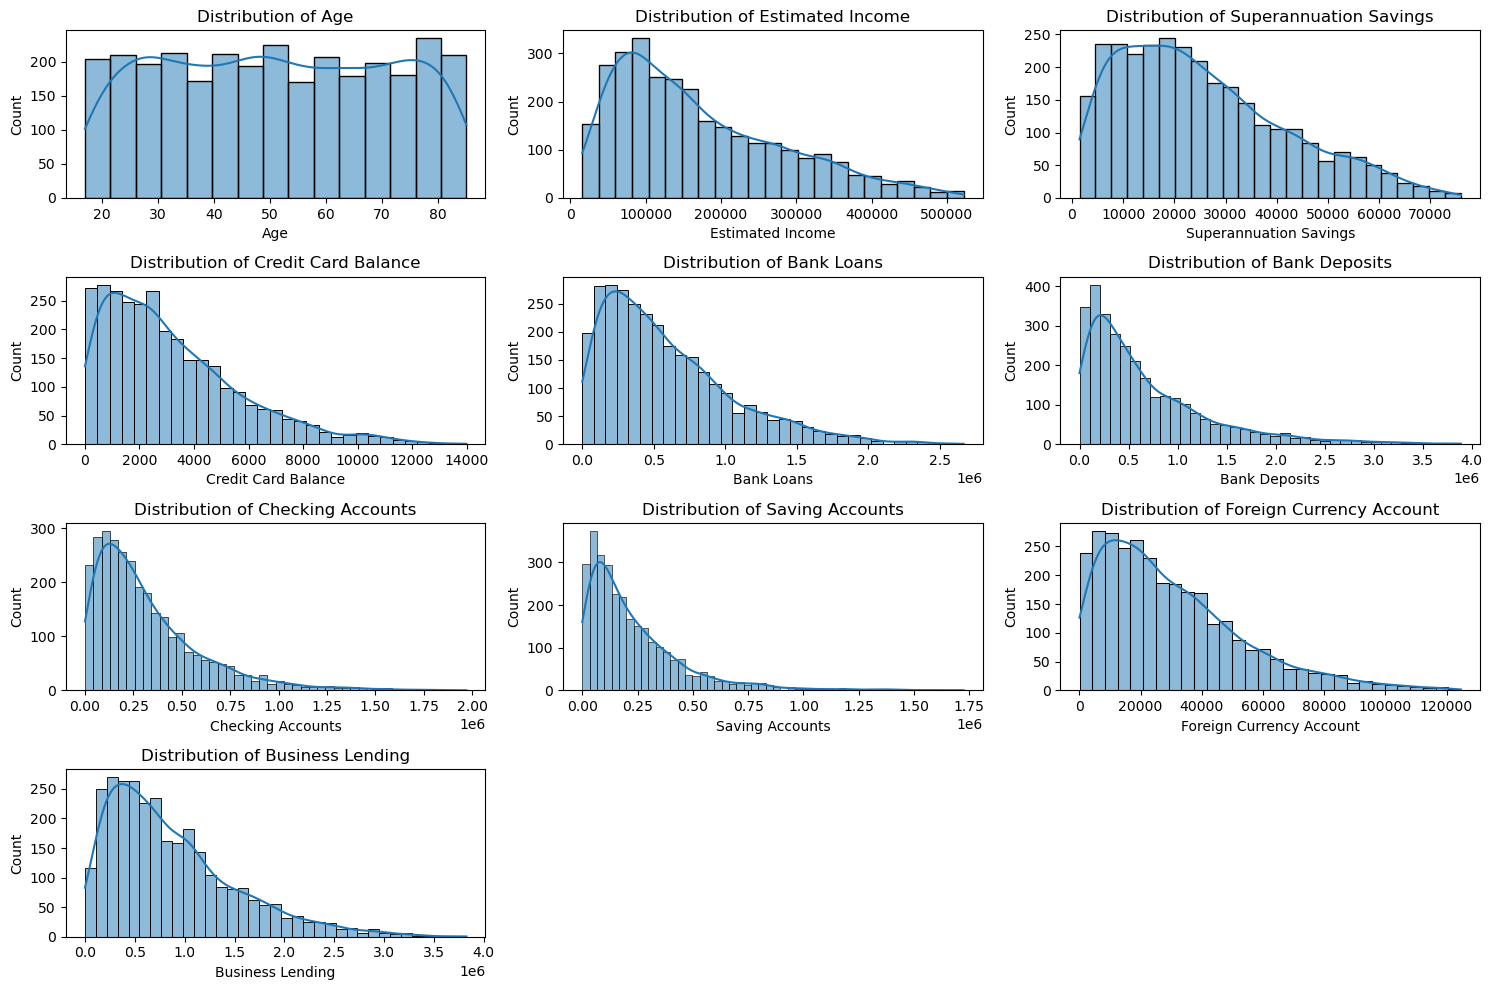

In [31]:
# Distribution analysis of numerical features

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(data=bank_df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Insight: Correlation Analysis

The correlation heatmap shows that Bank Deposits have a strong positive relationship with Checking Accounts and Saving Accounts, indicating that customers with higher deposits usually maintain higher balances across multiple accounts.

Business Lending and Bank Loans show moderate relationships with several financial variables, suggesting that borrowing activity is connected with overall customer financial behavior. Properties Owned has very weak correlation with most banking variables, which indicates that property ownership may not strongly depend on account balances, deposits, or loans in this dataset.

Overall, the correlation analysis helps identify important financial relationships that support customer segmentation, risk assessment, and banking strategy.

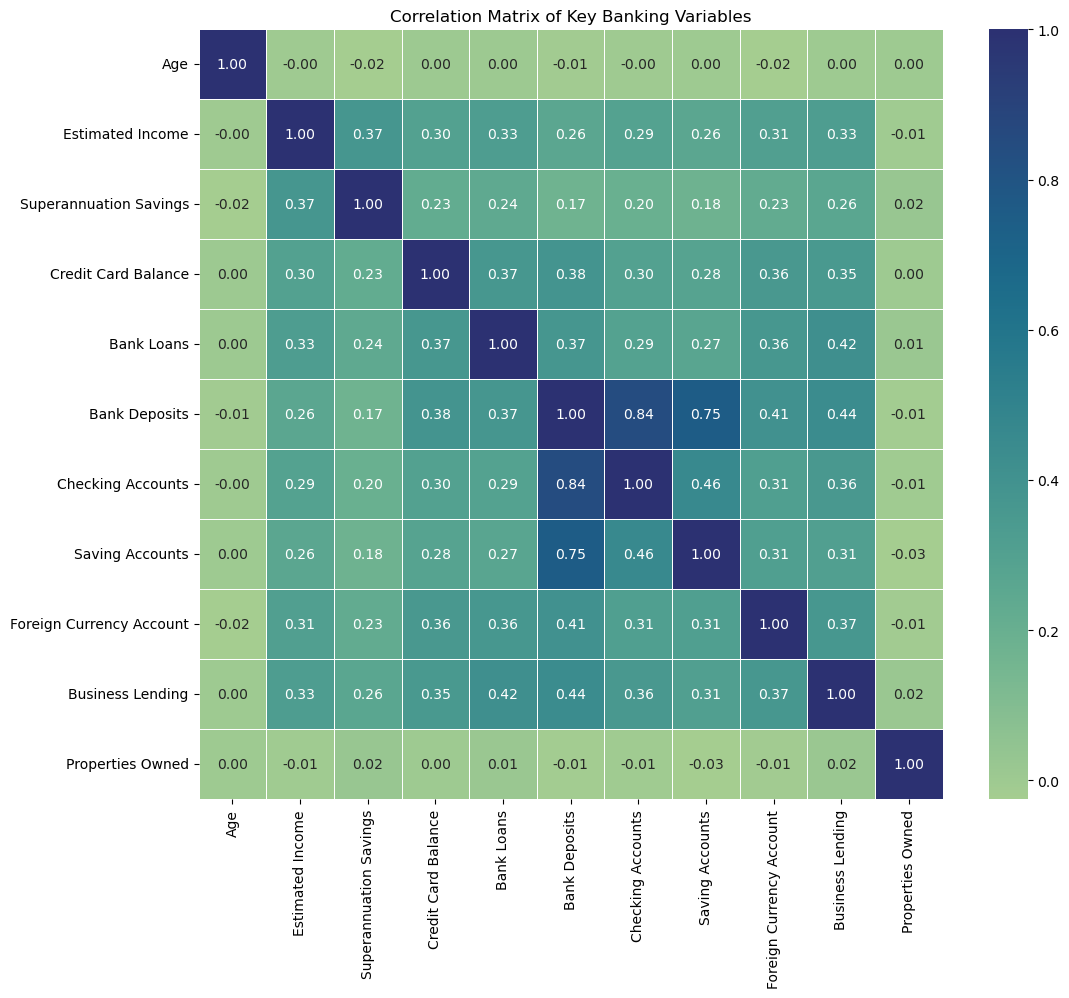

In [32]:
# Correlation analysis of key numerical banking features

correlation_cols = [
    'Age',
    'Estimated Income',
    'Superannuation Savings',
    'Credit Card Balance',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account',
    'Business Lending',
    'Properties Owned'
]

correlation_matrix = bank_df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Key Banking Variables')
plt.show()

## Final Insights

The complete EDA provides a comprehensive understanding of customer behavior, financial patterns, and risk dynamics within the banking dataset.

### 1. Customer Distribution (Univariate Analysis)
The dataset shows a diverse customer base across different nationalities, occupations, and loyalty segments. European and Asian customers dominate the dataset, while most customers fall under mid-level loyalty classifications such as Silver and Gold. Fee structures are primarily concentrated in High and Medium categories, indicating a strong base of active banking users.

### 2. Customer Segmentation Patterns (Bivariate Analysis)
Bivariate analysis reveals clear relationships between customer attributes:
- Certain nationalities show higher representation across multiple banking categories.
- Customers with higher loyalty classifications tend to engage more with banking services.
- Fee structure and credit card ownership patterns indicate that customers with higher engagement levels tend to utilize more financial products.

### 3. Financial Behavior Trends (Numerical Analysis)
The numerical distributions highlight important financial patterns:
- Most financial variables such as Bank Deposits, Loans, and Savings are right-skewed, indicating that a small group of customers holds significantly higher balances.
- Estimated Income shows a wide spread, suggesting diverse income groups within the dataset.
- Credit Card Balances and Loans follow similar distributions, reflecting consistent borrowing behavior among customers.

### 4. Risk and Income Relationships
Income segmentation indicates that higher-income customers generally maintain larger deposits and balances, making them key contributors to bank revenue. Additionally, risk-weighted customers show increasing loan values, suggesting that higher risk categories are associated with higher borrowing levels.

### 5. Correlation Insights
The correlation analysis reveals strong relationships between key financial variables:
- Bank Deposits, Checking Accounts, and Saving Accounts are highly correlated, indicating that customers with high deposits tend to maintain multiple active accounts.
- Moderate correlations between Loans, Credit Card Balances, and Business Lending suggest interconnected borrowing behavior.
- Properties Owned shows very weak correlation with most variables, implying that property ownership is influenced by external factors beyond banking activity.

### 6. Business Implications
- High-value customers can be identified based on deposit and account balances.
- Risk segmentation can help in identifying potential high-risk borrowers.
- Cross-selling opportunities exist among customers holding multiple accounts and financial products.
- Premium banking services can be targeted toward high-income and high-deposit customers.

### Overall Conclusion
The dataset demonstrates strong financial relationships, clear customer segmentation, and identifiable high-value customer groups. These insights can support data-driven decision-making in customer targeting, risk management, and business strategy optimization.